# Immunization & SIR simulations on artificial networks


### Simulation workflow

Generally, the simulations work as follows:
- *Network generation*: 
    - generate $n_{nw\_reps}$ network instances for each modularity setting (corresponding to different numbers of rewiring steps) using the method described by Salathé-Jones (2010). On each instance, run the immunization and SIR simulation steps.
- *Immunization*:
    - set desired immunization coverage(s), and run each of the implemented algorithms (Random, degree-based, ACQ, CBF, BHD, BNI-LI) on the given network instance, for each obtaining a set of immunized nodes corresponding to the desired coverage
- *SIR simulation*
    - specify settings of transmission rate $\beta$, recovery rate $\gamma$ to explore
    - perform SIR simulations with the EoN module, setting sets of immunized nodes obtained from the algorithms in the previous step as initial recovered nodes (before the first infections)
    - per combination of $\beta$, $\gamma$, set of immunized nodes obtained from a single combination of algorithm and coverage setting, perform $n_{sir\_reps}=100$ repetitions of the SIR simulation.


In [1]:
# library imports
import numpy as np   
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import immunization_funcs as imf # this is where the immunization strategies are implemented, see immunization_funcs.py
import sim_funcs as sf # this contains the simulation sweeps

### Running simulations

In [2]:
# parameter ranges
rewire_step_list = np.linspace(0, 2000, 11) # 11 values
coverage_list = np.arange(0.05, 0.31, 0.02) # 15 values
beta_list = np.arange(0.04, 0.105, 0.02) # 5 values ?
gamma_list = np.arange(0.1, 0.55, 0.1) # 5 values?
n_network_reps = 1
n_sir_reps = 100 

# warning, this sim takes AGES to run
#sf.run_gen_sweep(rewire_step_list, coverage_list, beta_list, gamma_list, n_network_reps=n_network_reps, n_sir_reps=n_sir_reps, output_path='results/basic_sweep.parquet', resume=False)

## Analysing & plotting simulation results

Let's start by setting up some constants and functions:

In [3]:
# the result metrics we collected
METRICS = ["final_attack_ratio", "peak_prevalence", "duration"]
METRIC_LABELS = {
    "final_attack_ratio": "Final attack ratio",
    "peak_prevalence": "Peak prevalence",
    "duration": "Duration",
}
METRIC_TITLES = ["Final Attack Ratio", "Peak Prevalence", "Epidemic Duration"]

# Columns that encode ids of simulation reps- we average and then drop them
DROP_COLS = ["network_rep", "sir_rep"]

# This well be for the columns listing the 'best' algorithms based on specific result metrics
# (used throughout compute_best_algorithms and plot_algo_heatmaps)
METRIC_MAP = {
    "alg_final":    "final_attack_ratio",
    "alg_peak":     "peak_prevalence",
    "alg_duration": "duration",
}

In [4]:
def avg_over_reps(
    df: pd.DataFrame,
    group_cols: list[str],
    drop_cols: list[str] = DROP_COLS,
) -> pd.DataFrame:
    """Average all numeric columns over SIR / network repetitions.

    Parameters
    ----------
    df         : raw simulation results
    group_cols : columns that uniquely identify the simulation parameter combination
                (here, should be rewire_steps, coverage, algorithm, beta, gamma)
    drop_cols  : repetetition index columns to discard after averaging

    Returns
    -------
    DataFrame with one row per condition, containing per-metric averages.
    """
    return (
        df.groupby(group_cols, as_index=False, observed=True)
          .mean(numeric_only=True)
          .drop(columns=[c for c in drop_cols if c in df.columns])
    )


def compute_best_algorithms(
    df_avg: pd.DataFrame,
    scenario_levels: list[str],
    metric_map: dict[str, str] = METRIC_MAP,
) -> pd.DataFrame:
    """For each parameter combo, find the algorithm with the best (lowest) value per result metric.

    Parameters
    ----------
    df_avg          : DataFrame averaged over replicates; must contain an
                      'algorithm' column plus all metric columns
    scenario_levels : columns that define a parameter combination, EXCLUDING 'algorithm'
    metric_map      : {output_column: result_metric_column}

    Returns
    -------
    DataFrame with parameter combos + any extra numeric columns (e.g. modularity)
    + one 'alg_*' column per metric holding the best algorithm's name.

    """
    grouped = df_avg.groupby(scenario_levels)

    # Carry forward the mean of numeric columns that are neither combo
    # nor metrics (e.g. modularity when grouping by rewire_steps).
    metric_vals  = set(metric_map.values())
    extra_numeric = [
        c for c in df_avg.select_dtypes("number").columns
        if c not in scenario_levels and c not in metric_vals
    ]

    if extra_numeric:
        best = grouped[extra_numeric].mean().reset_index()
    else:
        best = grouped.size().reset_index(name="_n").drop(columns="_n")

    for out_col, metric in metric_map.items():
        best_idx      = grouped[metric].idxmin()          # integer row labels
        best[out_col] = df_avg.loc[best_idx, "algorithm"].to_numpy()

    return best

##########################################
# and the visualisation funcs
##########################################
def make_color_encoding(algorithms: list[str], palette = None):
    """Make categorical colour encoding for a list of algorithms to be able to plot them
    as a heatmap with seaborn.

    Parameters
    ----------
    algorithms     : list of algorithm names for heatmap
    Returns
    -------
    algo_to_code   : {algorithm_name: integer_code}
    palette        : list of RGB tuples
    cmap           : ListedColormap
    norm           : BoundaryNorm
    legend_handles : list of Patch objects suitable for ax.legend(handles=...)
    """
    algorithms   = sorted(set(algorithms))
    n            = len(algorithms)
    algo_to_code = {alg: i for i, alg in enumerate(algorithms)}
    if palette is None:
        palette      = sns.color_palette("tab10", n_colors=n)
    cmap         = mcolors.ListedColormap(palette)
    norm         = mcolors.BoundaryNorm(np.arange(-0.5, n + 0.5, 1), ncolors=n)
    legend_handles = [
        mpatches.Patch(facecolor=palette[i], label=algorithms[i])
        for i in range(n)
    ]
    return algo_to_code, palette, cmap, norm, legend_handles


def _pivot_column(
    df: pd.DataFrame,
    col: str,
    algo_to_code: dict,
    row: str = "coverage",
    col_: str = "modularity",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Pivot a best-algorithm column into numeric-code and label DataFrames,
    to bring it in the format needed for the seaborn heatmap
    """
    df = df.copy()
    df[col + "_code"] = df[col].map(algo_to_code)
    pivot_code  = df.pivot(index=row, columns=col_, values=col + "_code").iloc[::-1]
    pivot_label = df.pivot(index=row, columns=col_, values=col).iloc[::-1]
    return pivot_code, pivot_label


def plot_algo_heatmaps(
    best_filtered: pd.DataFrame,
    algo_to_code: dict,
    cmap,
    norm,
    legend_handles: list,
    metric_map: dict[str, str] = METRIC_MAP,
    col_titles: list[str] = METRIC_TITLES,
    suptitle: str = "Best-performing algorithm by metric",
    save_path: str | None = None,
    annotate = True,
) -> plt.Figure:
    """Make vertically-stacked figure with the best-algorithm heatmaps for each result metric.

    Parameters
    ----------
    best_filtered  : output of compute_best_algorithms, filtered to a single
                     (beta, gamma) slice; must contain 'coverage' and
                     'modularity' (already rounded) with unique combinations.
    algo_to_code   : from make_color_encoding
    cmap / norm    : from make_color_encoding
    legend_handles : from make_color_encoding
    metric_map     : same mapping passed to compute_best_algorithms
    col_titles     : human-readable panel titles (same order as metric_map keys)
    save_path      : if given, save figure to this path at 300 dpi
    annotate       : Whether to annotate the heatmap panels.
    """
    col_names = list(metric_map.keys())
    n_panels  = len(col_names)
    fig, axes = plt.subplots(n_panels, 1, figsize=(9, 5 * n_panels))
    if n_panels == 1:
        axes = [axes]

    for ax, col, title in zip(axes, col_names, col_titles):
        pivot_code, pivot_label = _pivot_column(best_filtered, col, algo_to_code)
        sns.heatmap(
            pivot_code,
            ax=ax,
            cmap=cmap,
            norm=norm,
            linewidths=0.5,
            linecolor="black",
            annot=pivot_label if annotate else None,
            fmt="",
            annot_kws={"size": 10, "color": "black"},
            cbar=False,
        )
        ax.set_title(f"Best algorithm — {title}", fontsize=12, pad=10)
        ax.set_xlabel("Modularity", fontsize=12)
        ax.set_ylabel("Coverage",   fontsize=12)
        ax.legend(
            handles=legend_handles,
            title="Algorithm",
            loc="upper right",
            bbox_to_anchor=(1.5, 1),
            frameon=True,
            fontsize=10,
        )

    plt.suptitle(suptitle, fontsize=14, y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


def plot_metrics(
    data: pd.DataFrame,
    x_col: str,
    slice_col: str,
    slice_val: float,
    *,
    x_label: str,
    slice_label: str,
    metrics: list[str] = METRICS,
    metric_labels: dict = METRIC_LABELS,
    save_path: str | None = None,
) -> plt.Figure:
    """Draw a figure with one panel per result metric using seaborn lineplot.

    Parameters
    ----------
    data         : pre-filtered DataFrame (restricted to a single slice)
    x_col        : column for the x-axis ('modularity' or 'coverage')
    slice_col    : column used to select the slice (used in suptitle)
    slice_val    : value of that column (used in suptitle)
    x_label      : human-readable x-axis label
    slice_label  : human-readable slice description
    save_path    : if given, save figure to this path at 150 dpi
    """
    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4), sharey=False)
    fig.suptitle(f"{slice_label} = {slice_val:.2f}", fontsize=13, y=1.01)

    for ax, metric in zip(axes, metrics):
        sns.lineplot(
            data=data, x=x_col, y=metric,
            hue="algorithm", marker="o", ax=ax,
        )
        ax.set_xlabel(x_label,               fontsize=11)
        ax.set_ylabel(metric_labels[metric], fontsize=11)
        ax.set_title(metric_labels[metric],  fontsize=11)
        ax.get_legend().remove()
        ax.grid(alpha=0.3)

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title="Algorithm",
        loc="lower center",
        ncol=len(labels),
        bbox_to_anchor=(0.5, -0.12),
        frameon=True,
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return fig

### Battle of the BNI-LIs
We have 3 different versions of the BNI-LI algorithm, and each can run either with or without additional local probing, yielding 6 versions total. They are indexed as:

```Python
immunization_funcs = {  # dict of immunization functions
    'BNI-LI': imf.BNI_LI,
    'BNI-LI-local': lambda G, coverage: imf.BNI_LI(G, coverage, doLocalProbing=True),
    'BNI-LI-teleport': imf.BNI_LI_with_teleport,
    'BNI-LI-teleport-local': lambda G, coverage: imf.BNI_LI_with_teleport(G, coverage, doLocalProbing=True),
    'BNI-LI-random-trial': imf.BNI_LI_with_random_restarts,
    'BNI-LI-random-trial-local': lambda G, coverage: imf.BNI_LI_with_random_restarts(G, coverage, doLocalProbing=True),
    } 
```

So let's start by figuring out which one of these is the best version, based on the simulation data saved in `bni_li_sweep.parquet`.

In [5]:
bni_df = pd.read_parquet("results/bni_li_sweep.parquet")
print(bni_df.shape)
bni_df.head()

(1980000, 11)


,rewire_steps,network_rep,modularity,algorithm,coverage,beta,gamma,sir_rep,final_attack_ratio,peak_prevalence,duration
0,0,0,0.77999,BNI-LI,0.02,0.04,0.1,0,0.0045,0.0020,37.892353
1,0,0,0.77999,BNI-LI,0.02,0.04,0.1,1,0.0005,0.0005,2.170462
2,0,0,0.77999,BNI-LI,0.02,0.04,0.1,2,0.9030,0.2665,152.061050
3,0,0,0.77999,BNI-LI,0.02,0.04,0.1,3,0.9025,0.2555,131.536972
4,0,0,0.77999,BNI-LI,0.02,0.04,0.1,4,0.9190,0.2930,141.332062


First, let's average over the 100 SIR simulations for each constellation:

In [6]:
# average over SIR reps
# modularity is already a column in this dataset, so we group directly on it.
BNI_GROUP_COLS    = ["modularity", "algorithm", "coverage", "beta", "gamma"] # 
BNI_SCENARIO_COLS = ["modularity", "coverage", "beta", "gamma"]

bni_avg  = avg_over_reps(bni_df,
                         group_cols=BNI_GROUP_COLS,
                         drop_cols=["rewire_steps", "network_rep", "sir_rep"],
                         )

bni_best = compute_best_algorithms(bni_avg, BNI_SCENARIO_COLS)
bni_best.head()

,modularity,coverage,beta,gamma,alg_final,alg_peak,alg_duration
0,0.77999,0.02,0.04,0.1,BNI-LI-random-trial-local,BNI-LI-random-trial-local,BNI-LI-random-trial-local
1,0.77999,0.02,0.04,0.2,BNI-LI-random-trial,BNI-LI-random-trial,BNI-LI-random-trial
2,0.77999,0.02,0.04,0.3,BNI-LI-random-trial,BNI-LI-random-trial,BNI-LI-teleport-local
3,0.77999,0.02,0.04,0.4,BNI-LI,BNI-LI,BNI-LI
4,0.77999,0.02,0.04,0.5,BNI-LI-teleport-local,BNI-LI-random-trial-local,BNI-LI-random-trial-local


Which algorithm is best? I went with the oversimplified method of checking which algorithm yields the best (lowest) values for each of the result metrics, and then counting which one wins the most often.

In [7]:
# Count how often each BNI-LI variant achieves the best (lowest) value per metric.
best_counts = (
    pd.DataFrame({
        metric: bni_best[out_col].value_counts()
        for out_col, metric in METRIC_MAP.items()
    })
    .fillna(0)
    .astype(int)
    .sort_values("final_attack_ratio", ascending=False)
)
best_counts

,final_attack_ratio,peak_prevalence,duration
BNI-LI-random-trial-local,932,976,681
BNI-LI-random-trial,820,858,630
BNI-LI,439,438,552
BNI-LI-local,413,385,479
BNI-LI-teleport-local,353,333,464
BNI-LI-teleport,343,310,494


For fun, let's also do the heatmaps to check what succeeds where!

Heatmap grid: 15 coverage levels × 11 modularity levels


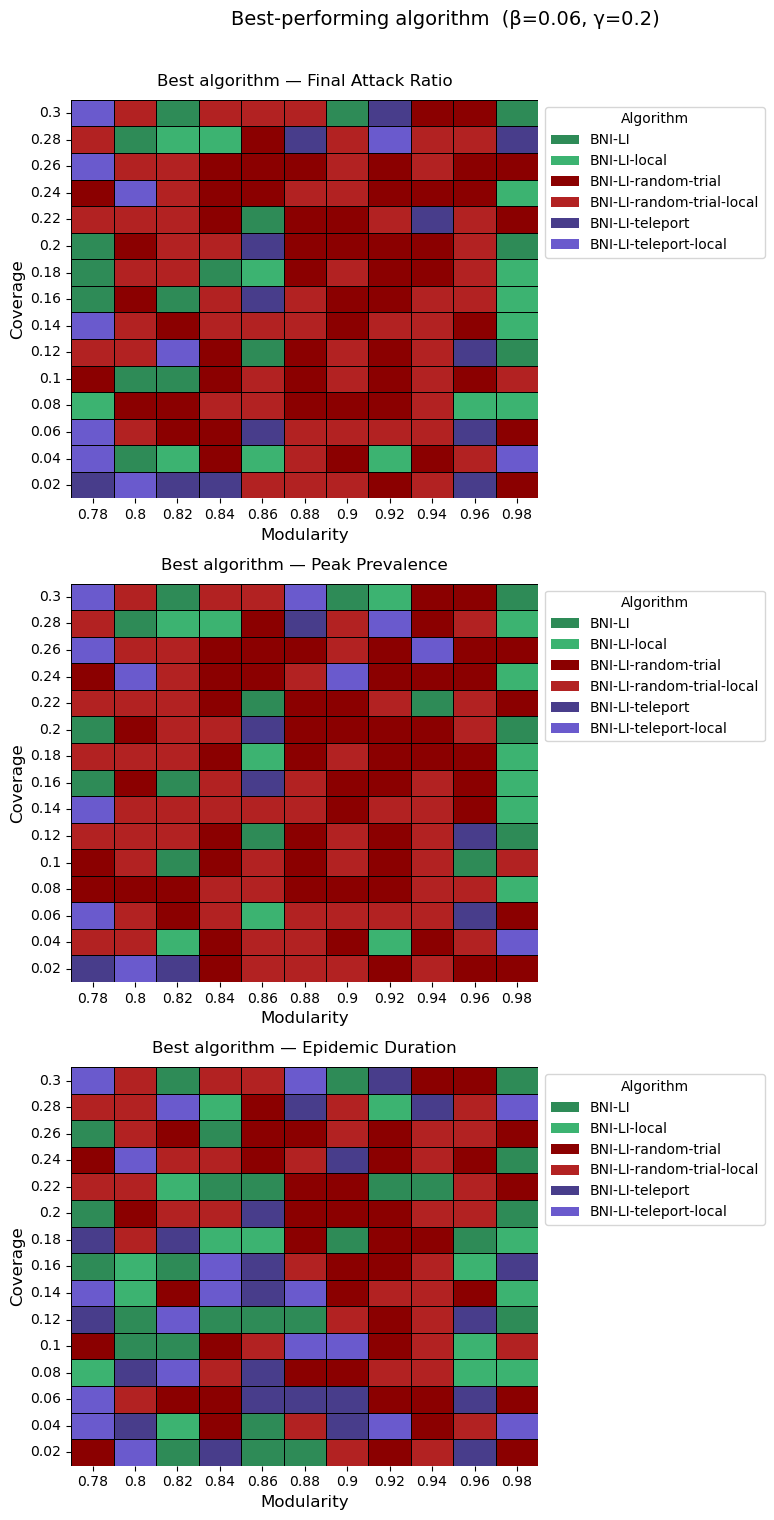

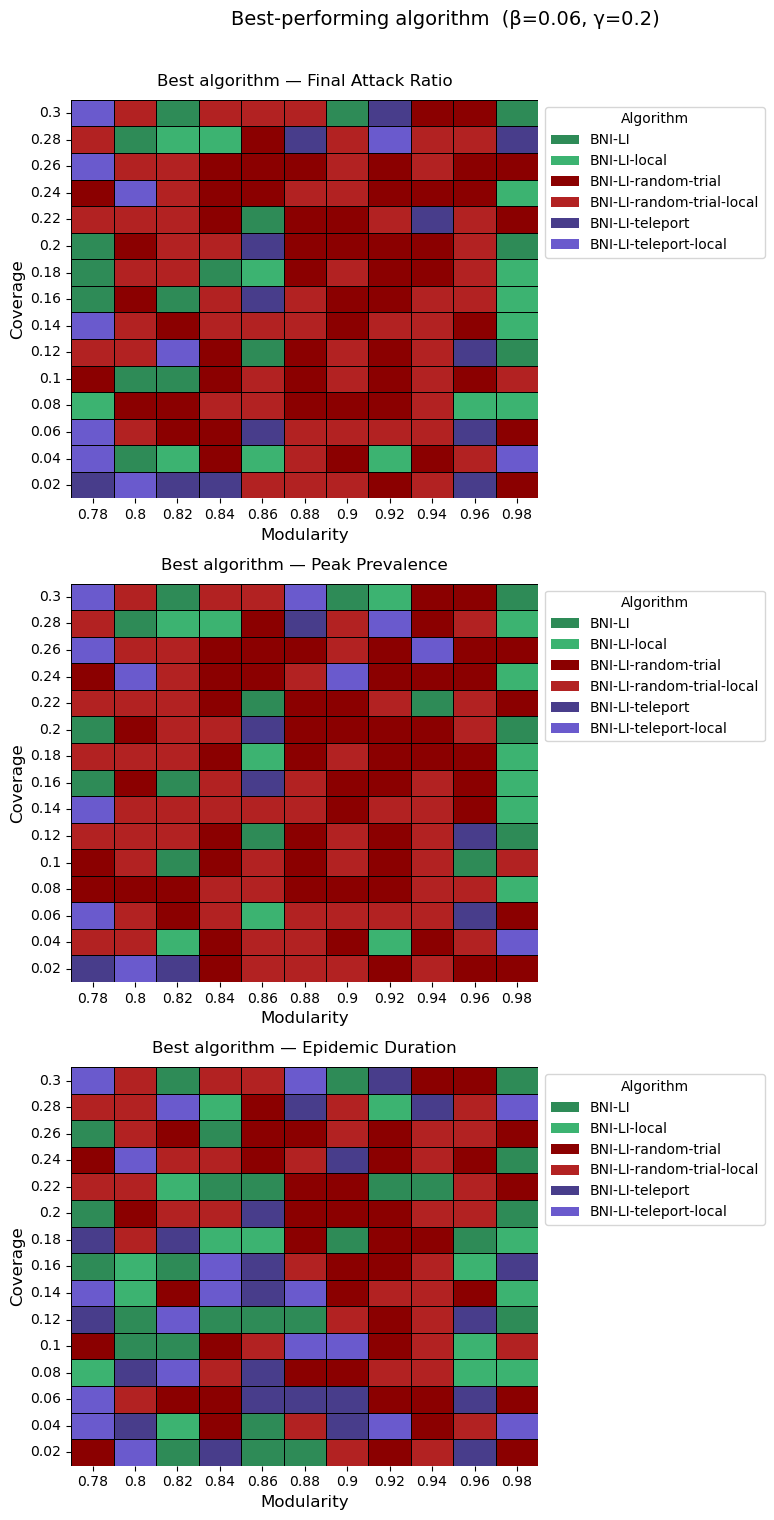

In [8]:
GAMMA_SLICE = 0.2
BETA_SLICE = 0.06

# Filter for the specific beta-gamma slice
best_filtered = (
    bni_best
    .loc[(bni_best["beta"] == BETA_SLICE) & (bni_best["gamma"] == GAMMA_SLICE)]
    .copy()
)
# round the modularity
best_filtered["modularity"] = best_filtered["modularity"].round(2)

# When two rewire_steps values round to the same modularity, resolve ties by
# majority vote (mode) across the duplicated (coverage, modularity) cells.
alg_cols = list(METRIC_MAP.keys())
best_filtered = (
    best_filtered
    .groupby(["coverage", "modularity"], as_index=False)[alg_cols]
    .agg(lambda x: x.mode().iat[0])
)

print(f"Heatmap grid: {best_filtered['coverage'].nunique()} coverage levels "
      f"× {best_filtered['modularity'].nunique()} modularity levels")

# ── Build shared colour encoding and draw the figure ─────────────────────────
all_algorithms = sorted(
    pd.concat([best_filtered[c] for c in alg_cols]).unique()
)

palette = ["seagreen", "mediumseagreen", "darkred", "firebrick", "darkslateblue", "slateblue"]
algo_to_code, palette, cmap, norm, legend_handles = make_color_encoding(all_algorithms, palette=palette)

plot_algo_heatmaps(
    best_filtered,
    algo_to_code=algo_to_code,
    cmap=cmap,
    norm=norm,
    legend_handles=legend_handles,
    suptitle=f"Best-performing algorithm  (β={BETA_SLICE}, γ={GAMMA_SLICE})",
    save_path="bni_algo_heatmaps.png",
    annotate=False
)

### Algorithm comparison

In [9]:
GROUP_COLS = ["rewire_steps", "modularity", "algorithm", "coverage", "beta", "gamma"] # 
SCENARIO_COLS = ["rewire_steps", "modularity", "coverage", "beta", "gamma"]

# (β, γ) slice used for the heatmap and curve plots
BETA_SLICE  = 0.06
GAMMA_SLICE = 0.2

# Modularity levels (expressed as rewire_steps) for the coverage-sweep curves
REWIRE_LEVELS = [200, 1800]

# Coverage levels for the modularity-sweep curves
COVERAGE_LEVELS = [0.06, 0.2]

In [10]:
# load file
df = pd.read_parquet("results/full_sweep.parquet") 
df["algorithm"]=df["algorithm"].astype("category")

# average over reps
df_avg  = avg_over_reps(df,
                         group_cols=GROUP_COLS,
                         drop_cols=["network_rep", "sir_rep"],
                         )

# get best algorithm for each metric
best = compute_best_algorithms(df_avg, SCENARIO_COLS)
best.head()

,rewire_steps,modularity,coverage,beta,gamma,alg_final,alg_peak,alg_duration
0,0,0.779993,0.02,0.04,0.1,BNI-LI,BNI-LI,BNI-LI
1,0,0.779993,0.02,0.04,0.2,Degree,Degree,ACQ
2,0,0.779993,0.02,0.04,0.3,BNI-LI,Degree,Degree
3,0,0.779993,0.02,0.04,0.4,BHD,BHD,BHD
4,0,0.779993,0.02,0.04,0.5,BHD,BHD,None


Heatmap grid: 15 coverage levels × 11 modularity levels


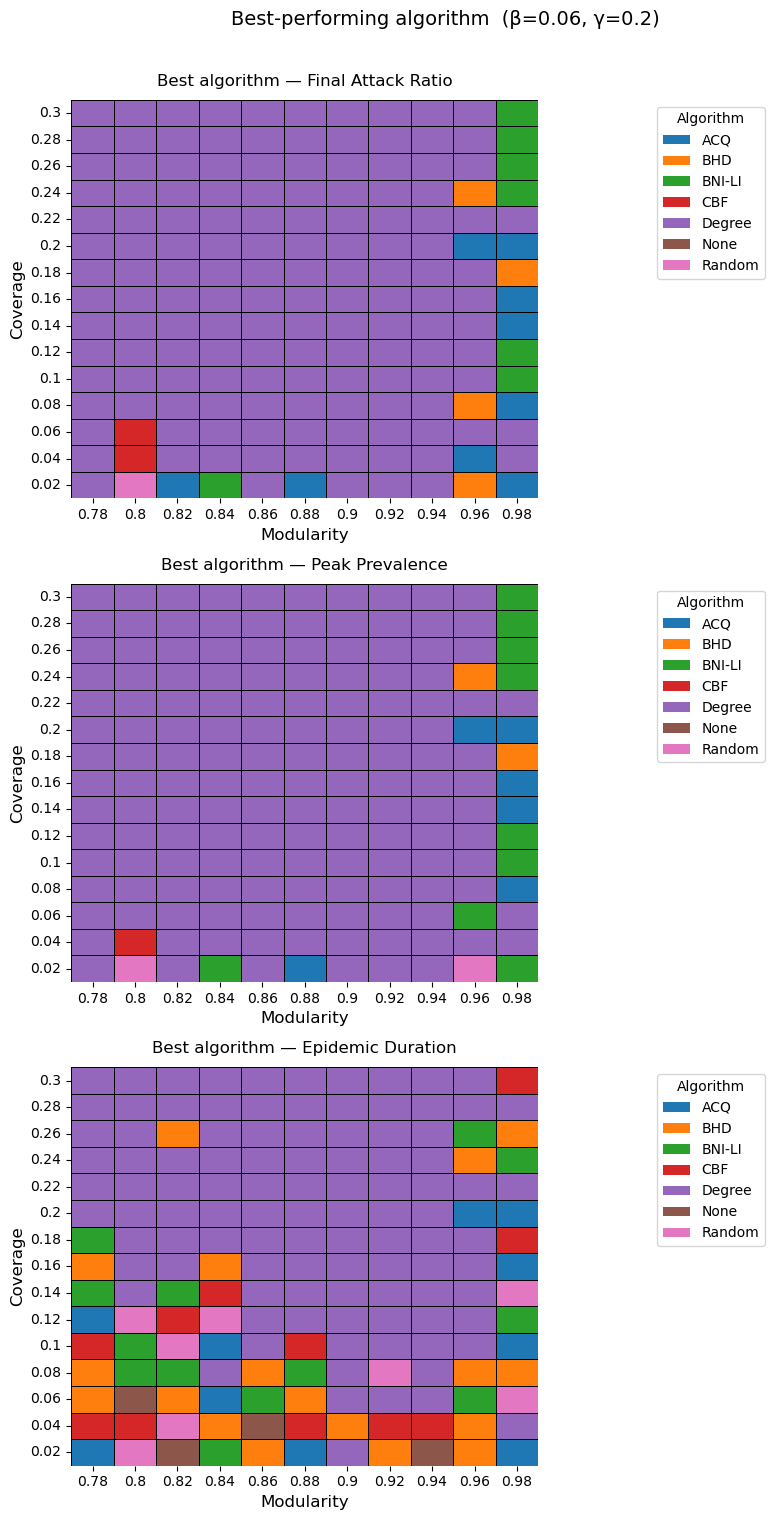

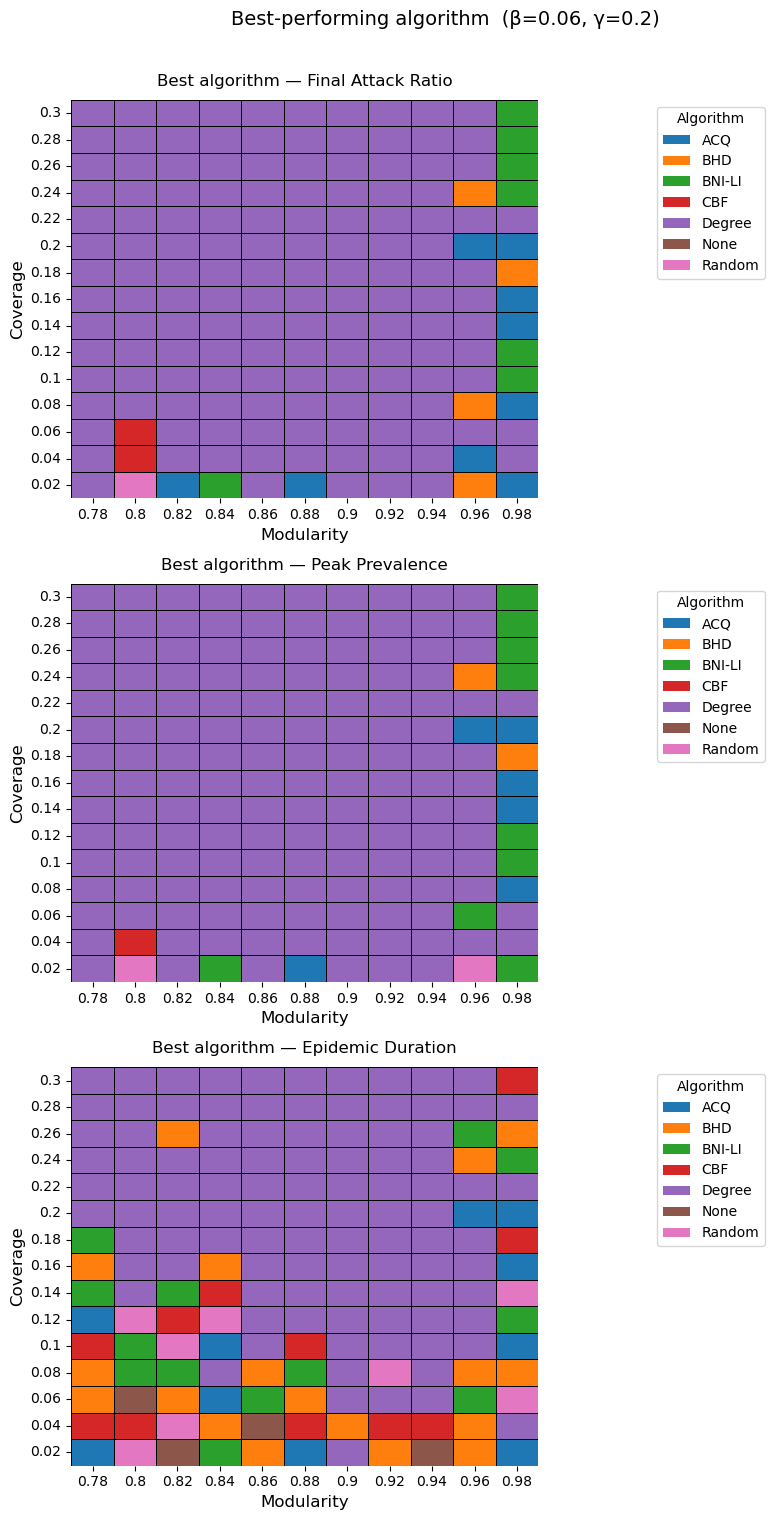

In [11]:
# Prepare the heatmap data 
best_filtered = (
    best
    .loc[(best["beta"] == BETA_SLICE) & (best["gamma"] == GAMMA_SLICE)]
    .copy()
)
best_filtered["modularity"] = best_filtered["modularity"].round(2)

# When two rewire_steps values round to the same modularity, resolve ties by
# majority vote (mode) across the duplicated (coverage, modularity) cells.
alg_cols = list(METRIC_MAP.keys())
best_filtered = (
    best_filtered
    .groupby(["coverage", "modularity"], as_index=False)[alg_cols]
    .agg(lambda x: x.mode().iat[0])
)

print(f"Heatmap grid: {best_filtered['coverage'].nunique()} coverage levels "
      f"× {best_filtered['modularity'].nunique()} modularity levels")

# Build shared colour encoding and draw the figure
all_algorithms = sorted(
    pd.concat([best_filtered[c] for c in alg_cols]).unique()
)
algo_to_code, palette, cmap, norm, legend_handles = make_color_encoding(all_algorithms)

plot_algo_heatmaps(
    best_filtered,
    algo_to_code=algo_to_code,
    cmap=cmap,
    norm=norm,
    legend_handles=legend_handles,
    suptitle=f"Best-performing algorithm  (β={BETA_SLICE}, γ={GAMMA_SLICE})",
    save_path="algo_heatmaps.png",
    annotate=False
)

Clearly the Degree-based immunization dominates, which is the one measure requiring global knowledge (degree of each node).

So et's exclude the degree-based (and the random one bc I should have done some proper reps & averaging there but didn't)

Heatmap grid: 15 coverage levels × 11 modularity levels


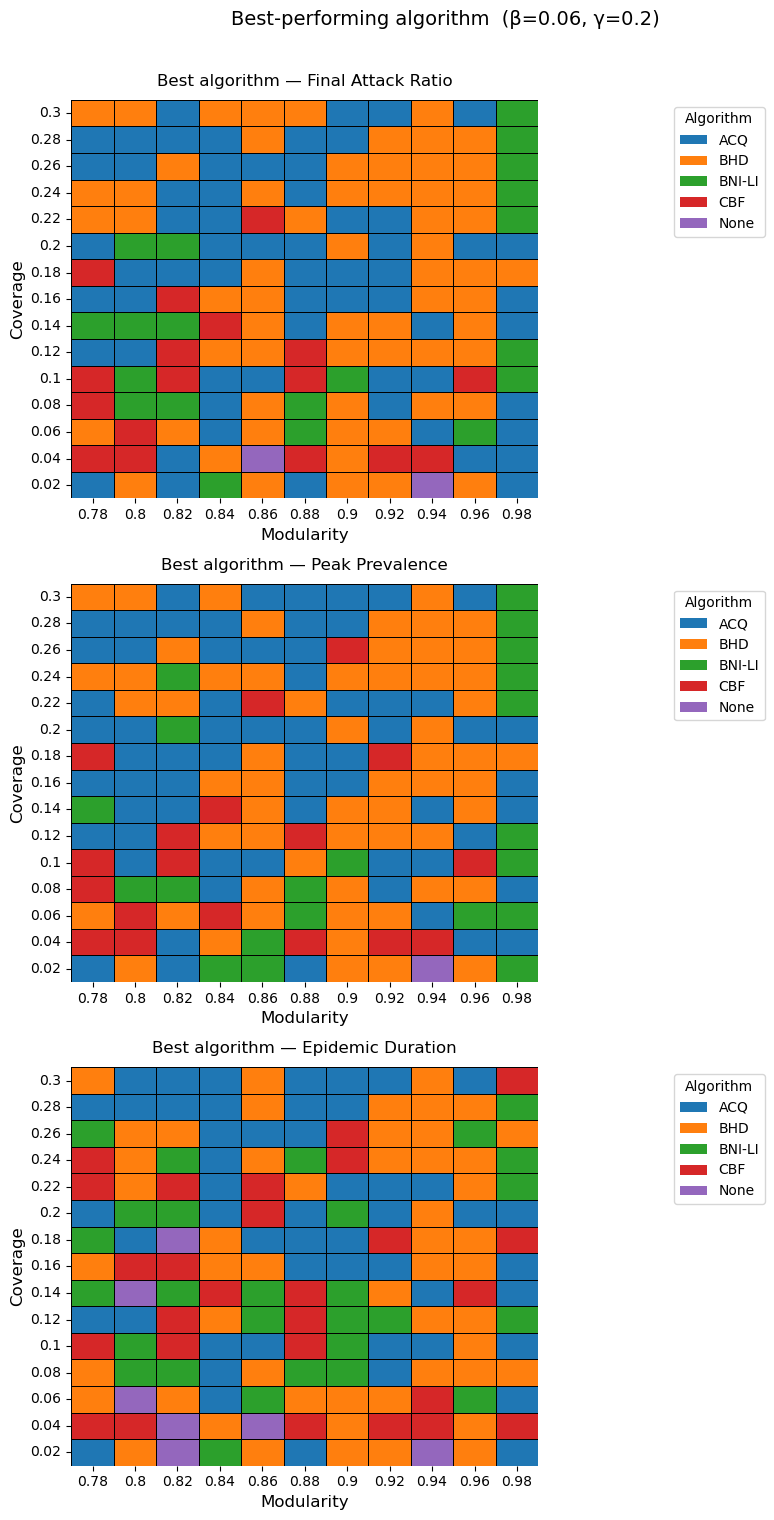

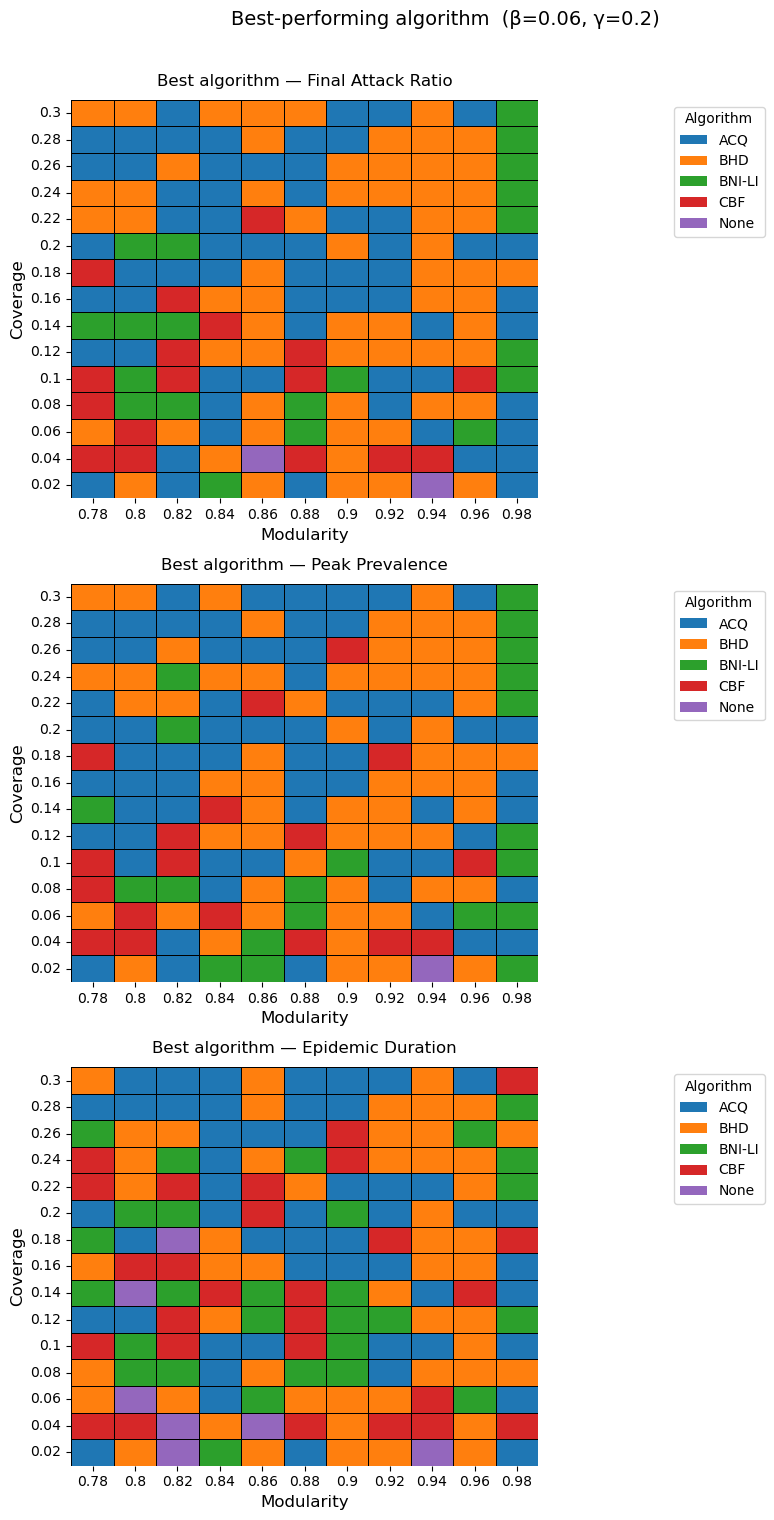

In [12]:
EXCLUDE_ALGORITHMS = ["Degree", "Random"]
df_avg = df_avg.query("algorithm not in @EXCLUDE_ALGORITHMS")


# get best algorithm for each metric
best = compute_best_algorithms(df_avg, SCENARIO_COLS)

# Prepare the heatmap data 
best_filtered = (
    best
    .loc[(best["beta"] == BETA_SLICE) & (best["gamma"] == GAMMA_SLICE)]
    .copy()
)
best_filtered["modularity"] = best_filtered["modularity"].round(2)

# When two rewire_steps values round to the same modularity, resolve ties by
# majority vote (mode) across the duplicated (coverage, modularity) cells.
alg_cols = list(METRIC_MAP.keys())
best_filtered = (
    best_filtered
    .groupby(["coverage", "modularity"], as_index=False)[alg_cols]
    .agg(lambda x: x.mode().iat[0])
)

print(f"Heatmap grid: {best_filtered['coverage'].nunique()} coverage levels "
      f"× {best_filtered['modularity'].nunique()} modularity levels")

# Build shared colour encoding and draw the figure
all_algorithms = sorted(
    pd.concat([best_filtered[c] for c in alg_cols]).unique()
)
algo_to_code, palette, cmap, norm, legend_handles = make_color_encoding(all_algorithms)

plot_algo_heatmaps(
    best_filtered,
    algo_to_code=algo_to_code,
    cmap=cmap,
    norm=norm,
    legend_handles=legend_handles,
    suptitle=f"Best-performing algorithm  (β={BETA_SLICE}, γ={GAMMA_SLICE})",
    save_path="algo_heatmaps_wo_degree.png",
    annotate=False
)

In [13]:
df_avg.head()

,rewire_steps,modularity,algorithm,coverage,beta,gamma,final_attack_ratio,peak_prevalence,duration
0,0,0.779993,ACQ,0.02,0.04,0.1,0.621190,0.183540,97.237373
1,0,0.779993,ACQ,0.02,0.04,0.2,0.093345,0.010085,38.048367
2,0,0.779993,ACQ,0.02,0.04,0.3,0.005705,0.001835,9.757036
3,0,0.779993,ACQ,0.02,0.04,0.4,0.002790,0.001335,6.044097
4,0,0.779993,ACQ,0.02,0.04,0.5,0.001480,0.001015,3.231841


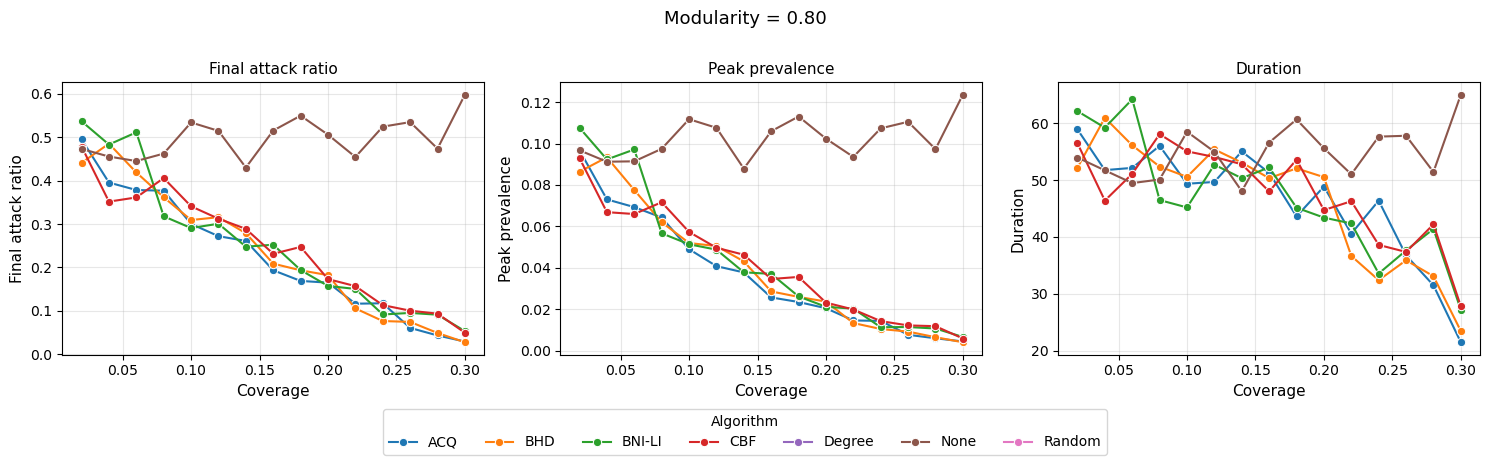

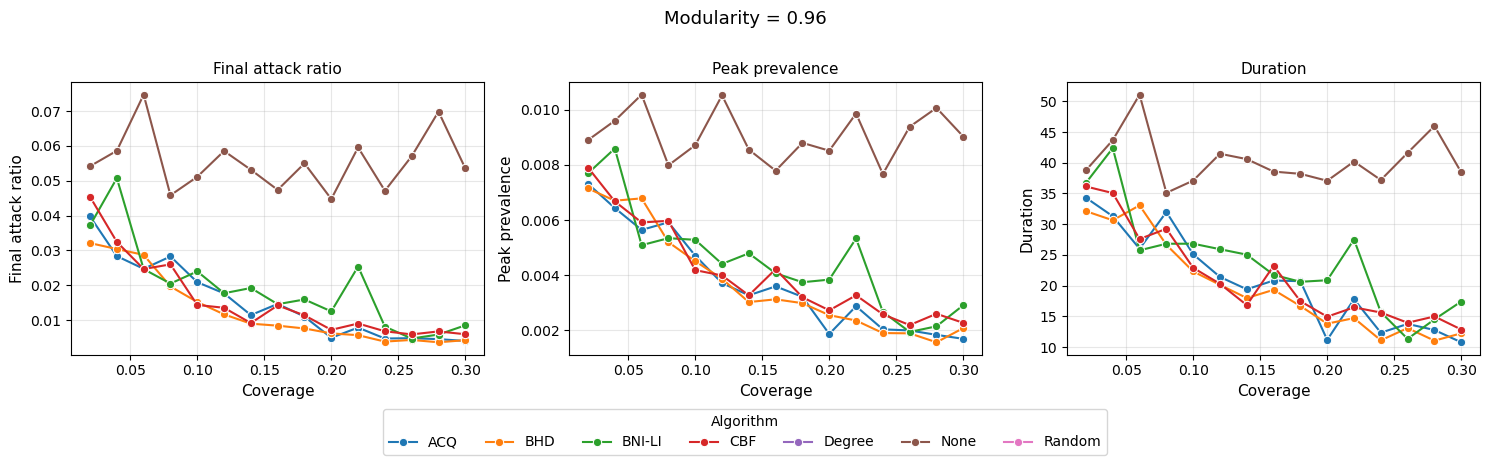

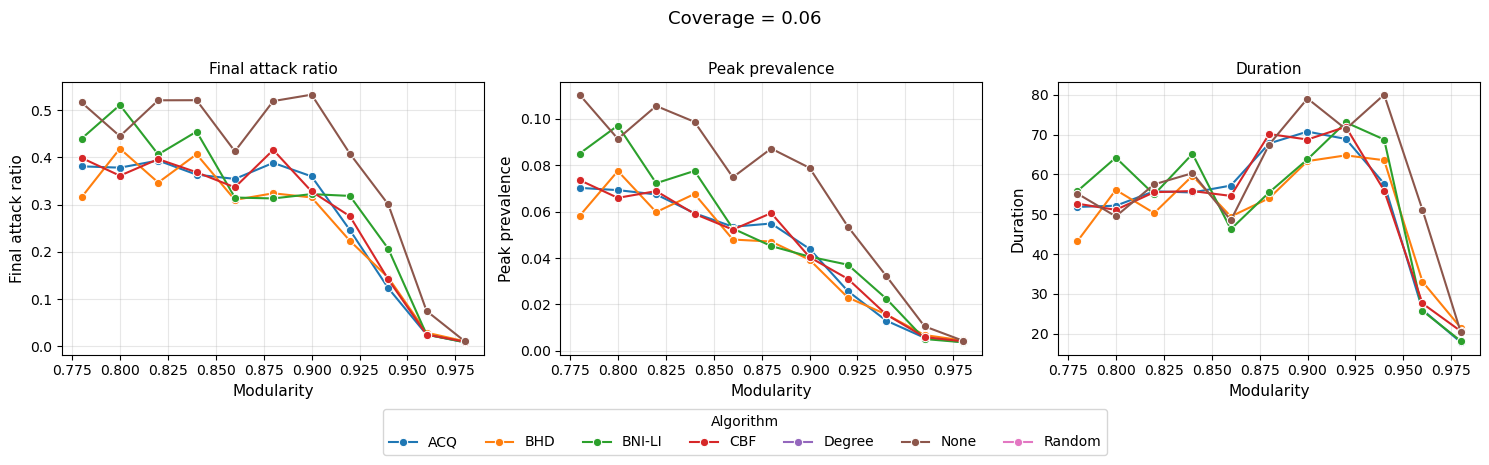

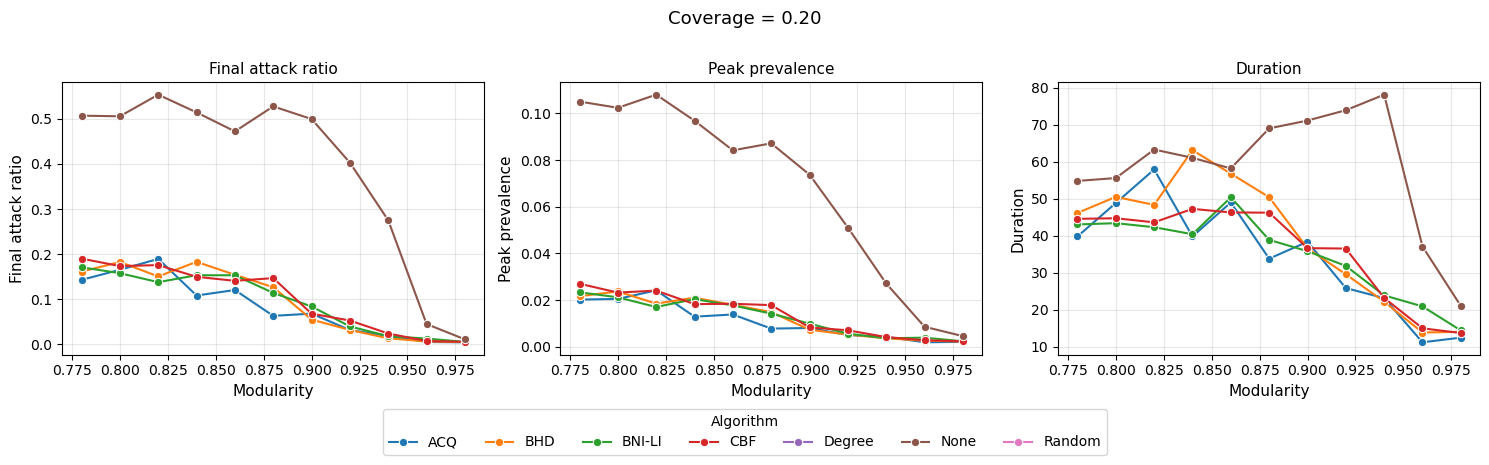

In [14]:
# Pre-filter to the chosen (β, γ) slice once — reused by both plot loops below.
df_sub = df_avg.query("gamma == @GAMMA_SLICE and beta == @BETA_SLICE")

# Build a rewire_steps → mean modularity lookup for readable slice labels.
rewire_to_mod = df_sub.groupby("rewire_steps")["modularity"].mean().round(2)

# Metric vs. coverage, for selected modularity (rewire_steps) levels 
for rw in REWIRE_LEVELS:
    subset  = df_sub.query("rewire_steps == @rw")
    mod_val = rewire_to_mod.loc[rw]
    plot_metrics(
        subset,
        x_col="coverage",
        slice_col="modularity",
        slice_val=mod_val,
        x_label="Coverage",
        slice_label="Modularity",
        save_path=f"metric_vs_coverage_mod{mod_val}.png",
    )

# Metric vs. modularity, for selected coverage levels 
for cov in COVERAGE_LEVELS:
    subset = df_sub.query("coverage == @cov")
    plot_metrics(
        subset,
        x_col="modularity",
        slice_col="coverage",
        slice_val=cov,
        x_label="Modularity",
        slice_label="Coverage",
        save_path=f"metric_vs_modularity_cov{cov}.png",
    )

Actually, let's merge the 2 dataframes and repeat the analysis:

In [15]:
# ── Load & combine ────────────────────────────────────────────────────────────
dfA = pd.read_parquet("results/bni_li_sweep.parquet")
dfB = pd.read_parquet("results/full_sweep.parquet")
df  = pd.concat([dfA, dfB], ignore_index=True)
df  = df.query("algorithm not in ['Degree', 'Random', 'BNI-LI', 'BNI-LI-local', 'BNI-LI-teleport', 'BNI-LI-teleport-local']")

Heatmap grid: 15 coverage levels × 11 modularity levels


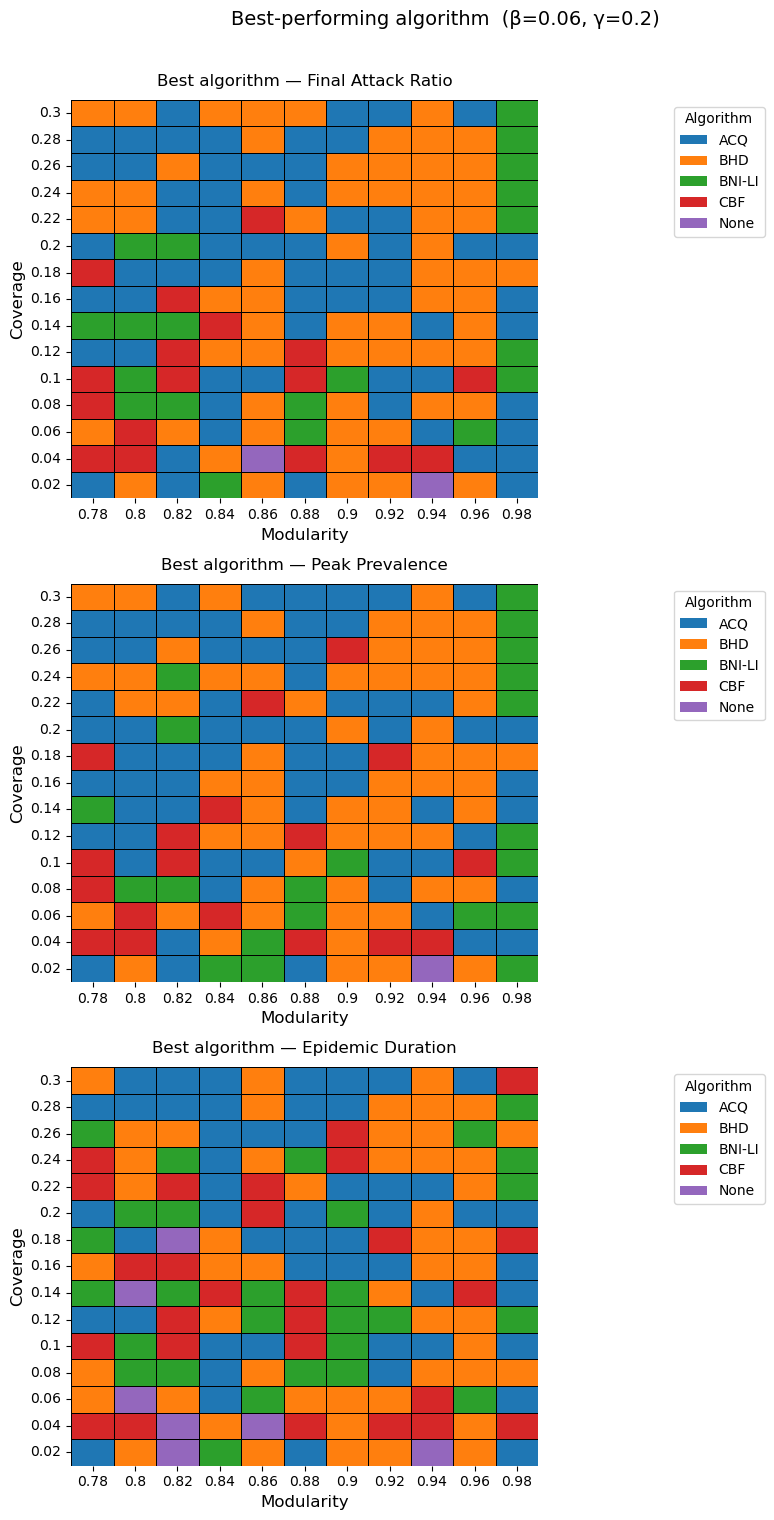

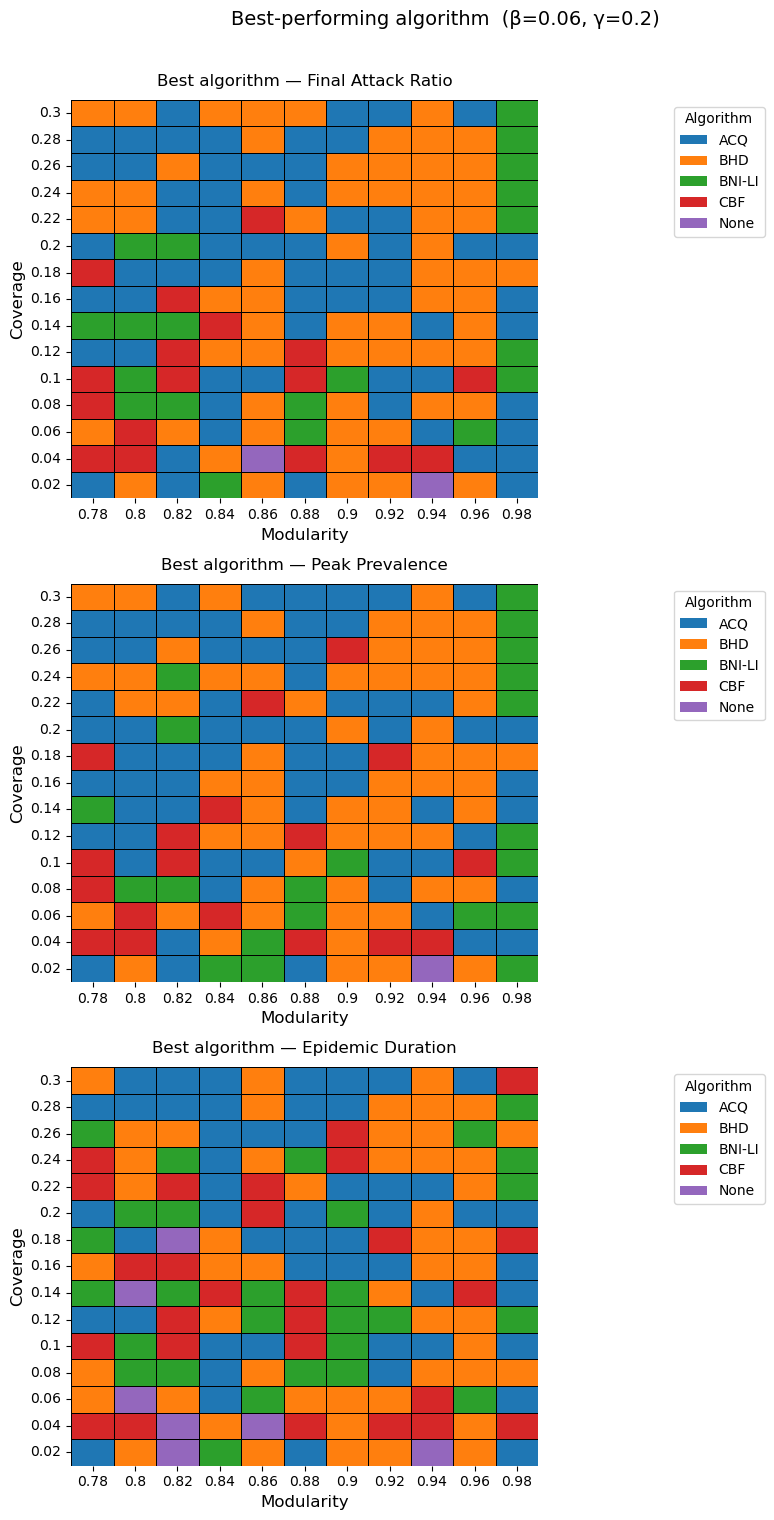

In [16]:
# get best algorithm for each metric
best = compute_best_algorithms(df_avg, SCENARIO_COLS)

# Prepare the heatmap data 
best_filtered = (
    best
    .loc[(best["beta"] == BETA_SLICE) & (best["gamma"] == GAMMA_SLICE)]
    .copy()
)
best_filtered["modularity"] = best_filtered["modularity"].round(2)

# When two rewire_steps values round to the same modularity, resolve ties by
# majority vote (mode) across the duplicated (coverage, modularity) cells.
alg_cols = list(METRIC_MAP.keys())
best_filtered = (
    best_filtered
    .groupby(["coverage", "modularity"], as_index=False)[alg_cols]
    .agg(lambda x: x.mode().iat[0])
)

print(f"Heatmap grid: {best_filtered['coverage'].nunique()} coverage levels "
      f"× {best_filtered['modularity'].nunique()} modularity levels")

# Build shared colour encoding and draw the figure
all_algorithms = sorted(
    pd.concat([best_filtered[c] for c in alg_cols]).unique()
)
algo_to_code, palette, cmap, norm, legend_handles = make_color_encoding(all_algorithms)

plot_algo_heatmaps(
    best_filtered,
    algo_to_code=algo_to_code,
    cmap=cmap,
    norm=norm,
    legend_handles=legend_handles,
    suptitle=f"Best-performing algorithm  (β={BETA_SLICE}, γ={GAMMA_SLICE})",
    save_path="algo_heatmaps_merged.png",
    annotate=False
)

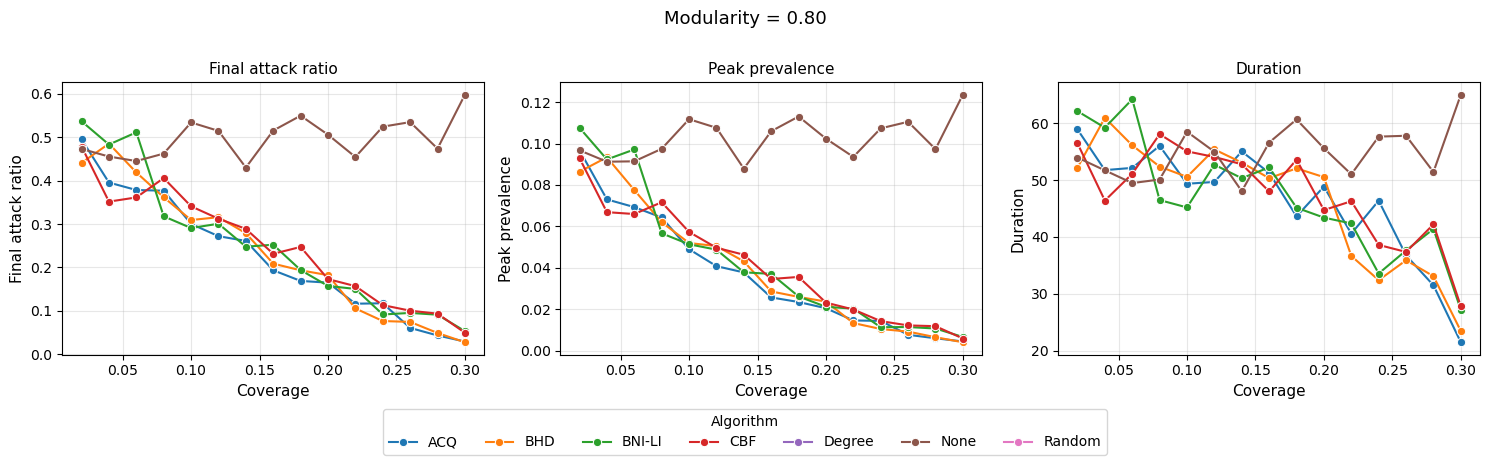

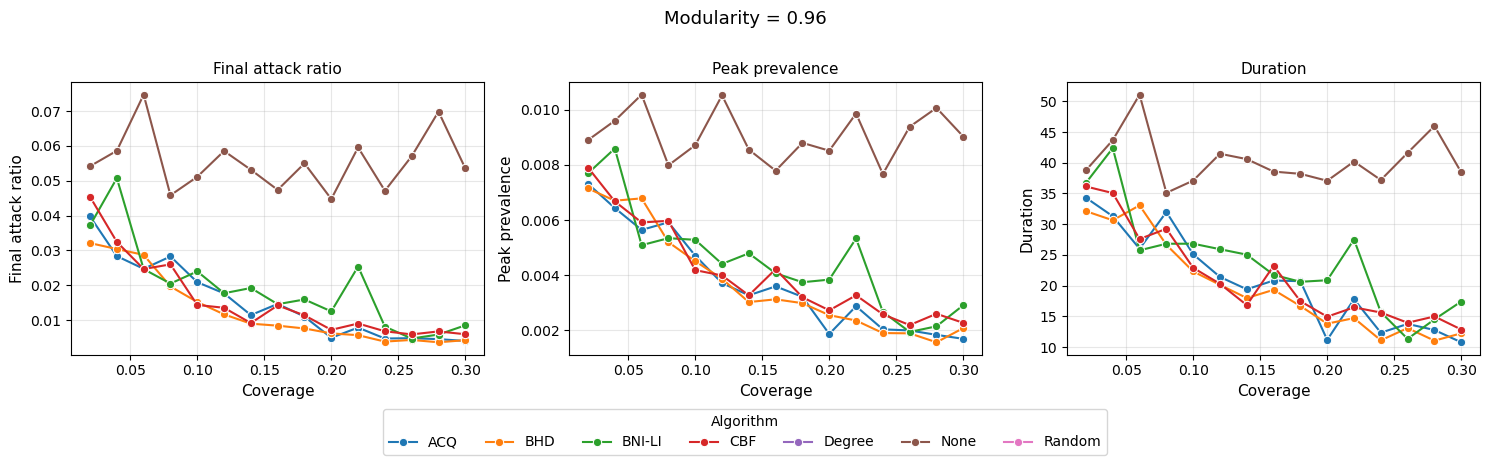

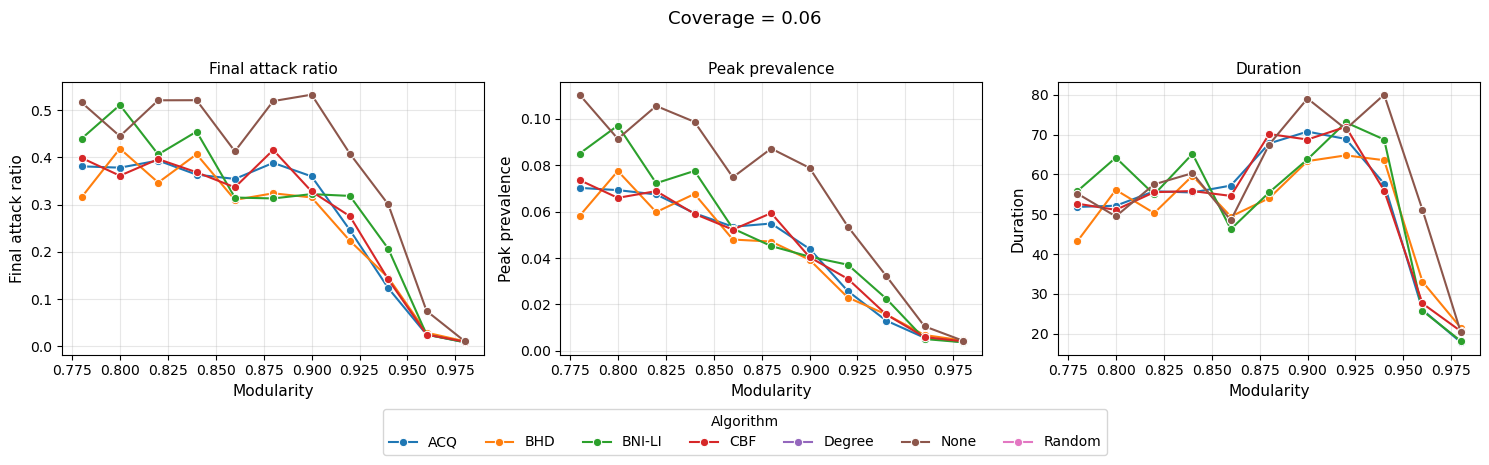

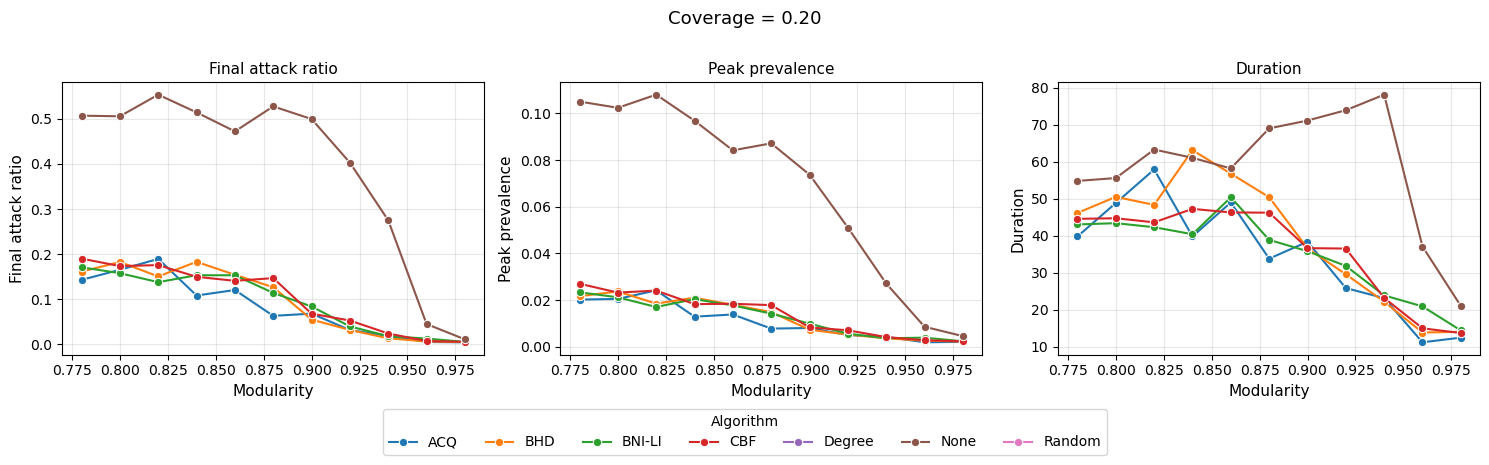

In [17]:
# Pre-filter to the chosen (β, γ) slice once — reused by both plot loops below.
df_sub = df_avg.query("gamma == @GAMMA_SLICE and beta == @BETA_SLICE")

# Build a rewire_steps → mean modularity lookup for readable slice labels.
rewire_to_mod = df_sub.groupby("rewire_steps")["modularity"].mean().round(2)

# Metric vs. coverage, for selected modularity (rewire_steps) levels 
for rw in REWIRE_LEVELS:
    subset  = df_sub.query("rewire_steps == @rw")
    mod_val = rewire_to_mod.loc[rw]
    plot_metrics(
        subset,
        x_col="coverage",
        slice_col="modularity",
        slice_val=mod_val,
        x_label="Coverage",
        slice_label="Modularity",
        save_path=f"metric_vs_coverage_mod{mod_val}.png",
    )

# Metric vs. modularity, for selected coverage levels 
for cov in COVERAGE_LEVELS:
    subset = df_sub.query("coverage == @cov")
    plot_metrics(
        subset,
        x_col="modularity",
        slice_col="coverage",
        slice_val=cov,
        x_label="Modularity",
        slice_label="Coverage",
        save_path=f"metric_vs_modularity_cov{cov}.png",
    )